# Linear regression - SSS vs SIC

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cartopy.crs as ccrs
from scipy.stats import t
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:36751")
client

<Client: 'tcp://127.0.0.1:36751' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [7]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [8]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

## Select days after sea ice minimum each year and mask SIC>15%

In [9]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [10]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [11]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [12]:
# select days after sea ice minimum for SIC and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,7)) # only upper 10 m

In [13]:
# look at depth of grid cell center and bottom of grid cell
print(salt_yrs.Z.values)
print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

[-0.5   -1.57  -2.79  -4.185 -5.78  -7.595 -9.66 ]
[ -1.    -2.14  -3.44  -4.93  -6.63  -8.56 -10.76]


In [14]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

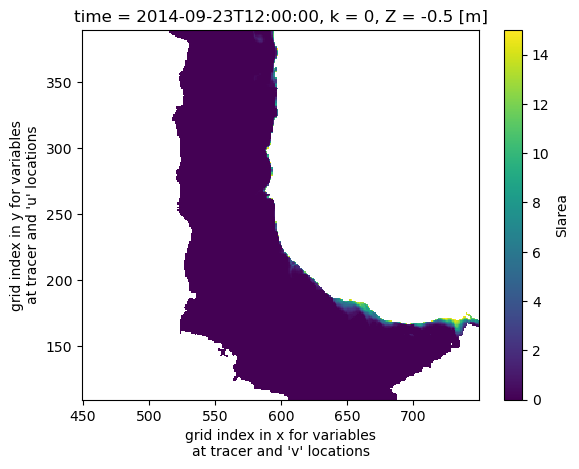

In [15]:
ice_yrs_masked.sel(time='2014').isel(time=0).plot();

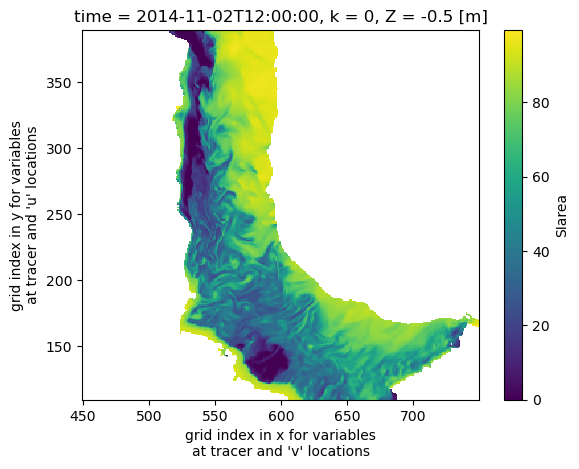

In [16]:
ice_yrs_masked.sel(time='2014').isel(time=40).plot();

## Calculate FWC

In [17]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [18]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [19]:
# mask land grid cells and where SIC>15% on ice minimum date
# ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

In [20]:
# determine the upper end of the dataset
fwc_yrs_masked.max().values

array(6.75552669)

In [24]:
# check shape of each dataset
print(fwc_yrs_masked.shape)
print(ice_yrs_masked.shape)

(733, 280, 300)
(733, 280, 300)


## Correlation coefficients for October of each year

In [32]:
def sig_corr(corr_da, n):
    """
    Determine which correlations are statistically significant
    Mask insignificant values in provided array and return only signficant values

    n : sample size
    corr_da : correlation coefficients
    """
    
    # compute the t-statistic
    t_stat = corr_da * np.sqrt((n - 2) / (1 - corr_da**2))

    # compute p-values using the survival function (1 - CDF)
    p_values = 2 * t.sf(np.abs(t_stat), df=n - 2)

    # determine significance at alpha=0.05
    alpha = 0.05
    # mask non-significant correlations
    corr_significant = corr_da.where(p_values < alpha)
    
    return corr_significant

In [26]:
# select only month of october for each year
fwc_oct_masked = fwc_yrs_masked.sel(time=fwc_yrs_masked['time'].dt.month == 10)
ice_oct_masked = ice_yrs_masked.sel(time=fwc_yrs_masked['time'].dt.month == 10)

In [38]:
corr_fwc_ice = xr.corr(fwc_oct_masked.sel(time='2019'), ice_oct_masked.sel(time='2019'), dim='time').compute()

In [39]:
significant_corr_fwc_ice = sig_corr(corr_fwc_ice, len(ice_oct_masked['time']))

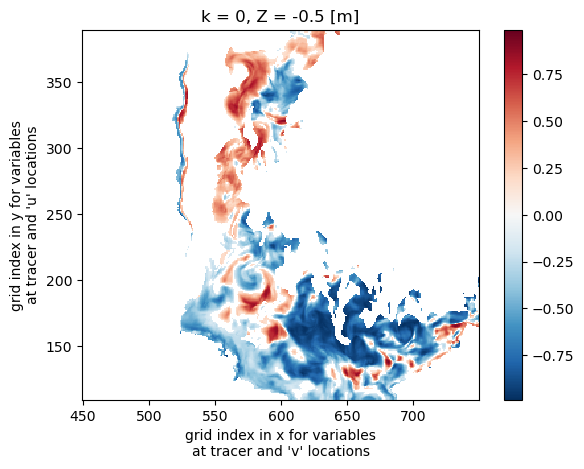

In [40]:
significant_corr_fwc_ice.plot();

## Plot time series of R2 for region each year

In [41]:
corr_fwc_sic = xr.corr(fwc_yrs_masked, ice_yrs_masked, dim=['i','j'])

In [42]:
significant_corr_fwc_sic = sig_corr(corr_fwc_sic, len(ice_yrs_masked['time']))

In [54]:
significant_corr_fwc_sic.sel(time='2019').max().values

array(0.58089615)

In [57]:
salt_yrs_masked = salt_yrs.where(land_sic_mask_yr)

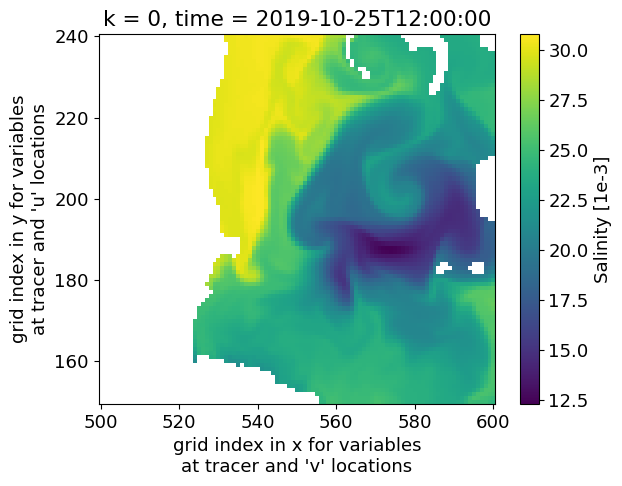

In [68]:
salt_yrs_masked.sel(time='2019-10-25',i=slice(500,600),j=slice(150,240)).isel(k=0,time=0).plot();
# ice_yrs_masked.sel(time='2019-10-25').isel(time=0).plot();

In [ ]:
salt_box = salt_yrs_masked.sel(time='2019-10-25',i=slice(500,600),j=slice(150,240)).isel(k=0,time=0)
ice_box = 

In [69]:
ice_below_50_mask = ice_yrs_masked<50

In [81]:
ice_below_50 = ice_yrs_masked.where(ice_below_50_mask)
sss_below_50 = salt_yrs_masked.isel(k=0).where(ice_below_50_mask)

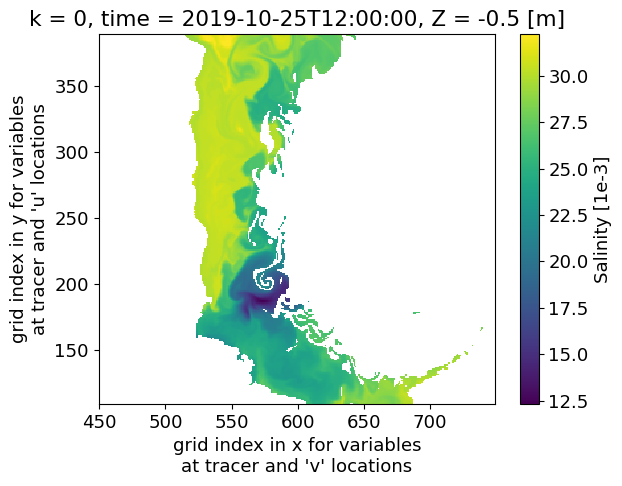

In [83]:
sss_below_50.sel(time='2019-10-25').plot();

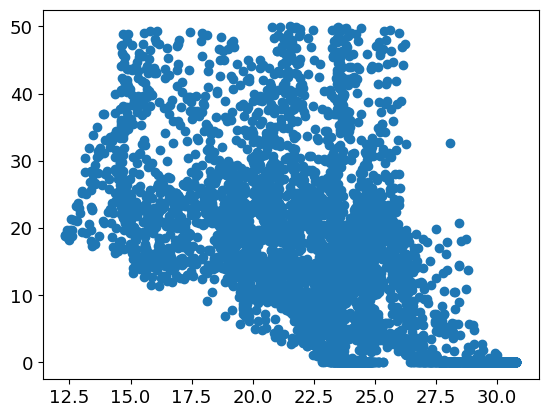

In [87]:
plt.scatter(sss_below_50.sel(time='2019-10-25',i=slice(500,600),j=slice(150,240)).values, ice_below_50.sel(time='2019-10-25',i=slice(500,600),j=slice(150,240)).values);

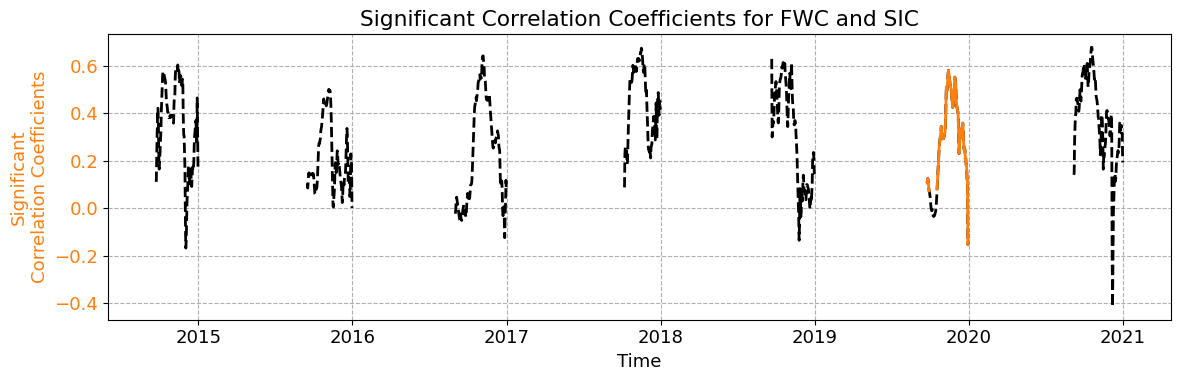

In [93]:
# Create a plot of coeff and sea ice cover
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(12, 4))

# Plot correlation coefficients on the primary axis
# corr_fwc_sic.plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
corr_fwc_sic_fill.plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
significant_corr_fwc_sic.sel(time='2019').plot(ax=ax1, color='tab:orange', label='Correlation Coefficients', linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Significant\nCorrelation Coefficients', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(linestyle='dashed')

# Create secondary axis for sea ice area
# ax2 = ax1.twinx()  # Create a second y-axis
# SIcover_beaufort_percent.plot(ax=ax2, color='tab:blue', label='Sea Ice Cover (%)', linewidth=2)
# ax2.set_ylabel('Sea Ice Cover (%)', color='tab:blue')
# ax2.tick_params(axis='y', labelcolor='tab:blue')

# Add a title and show the plot
ax1.set_title(r'Significant Correlation Coefficients for FWC and SIC')
# ax2.set_title("")
fig.tight_layout()

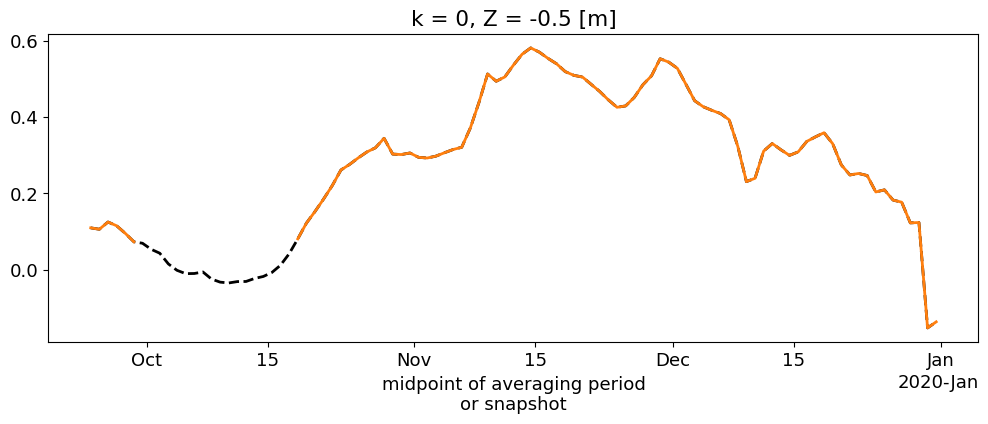

In [88]:
plt.rcParams.update({'font.size': 13})
fig, ax1 = plt.subplots(figsize=(12, 4))

corr_fwc_sic.sel(time='2019').plot(ax=ax1, color='k', linestyle='dashed', label='Correlation Coefficients', linewidth=2)
significant_corr_fwc_sic.sel(time='2019').plot(ax=ax1, color='tab:orange', label='Correlation Coefficients', linewidth=2)